In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
before_df=pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
df=pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
print("Dataset uploaded successfully")

Dataset uploaded successfully


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
print("no of duplicated rows : ", df.duplicated().sum())

no of duplicated rows :  0


In [ ]:
df.dropna(subset=['Sleep Disorder'], inplace=True)
df.drop(columns=['Sleep Duration'], inplace=True)
print("Null values in 'Sleep Disorder' column removed and 'Sleep Duration' column dropped.")

In [ ]:
print("Updated null values count:")
df.isnull().sum()

Updated null values count:


,0
Gender,0
Age,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
Heart Rate,0
Daily Steps,0
Sleep Disorder,0
Systolic Blood Pressure,0
Diastolic Blood Pressure,0


In [ ]:
print("no of duplicated Records : ",df.duplicated().sum())

no of duplicated Records :  0


In [ ]:
df.drop('Person ID', axis=1, inplace=True)
print("'Person ID' column dropped.")

'Person ID' column dropped.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155 entries, 3 to 373
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    155 non-null    int64  
 1   Age                       155 non-null    int64  
 2   Quality of Sleep          155 non-null    int64  
 3   Physical Activity Level   155 non-null    int64  
 4   Stress Level              155 non-null    int64  
 5   Heart Rate                155 non-null    int64  
 6   Daily Steps               155 non-null    int64  
 7   Sleep Disorder            155 non-null    int64  
 8   Systolic Blood Pressure   155 non-null    int64  
 9   Diastolic Blood Pressure  155 non-null    int64  
 10  Occupation_0              155 non-null    float64
 11  Occupation_1              155 non-null    float64
 12  Occupation_2              155 non-null    float64
 13  Occupation_3              155 non-null    float64
 14  Occupation_4   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155 entries, 3 to 373
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    155 non-null    int64  
 1   Age                       155 non-null    int64  
 2   Quality of Sleep          155 non-null    int64  
 3   Physical Activity Level   155 non-null    int64  
 4   Stress Level              155 non-null    int64  
 5   Heart Rate                155 non-null    int64  
 6   Daily Steps               155 non-null    int64  
 7   Sleep Disorder            155 non-null    int64  
 8   Systolic Blood Pressure   155 non-null    int64  
 9   Diastolic Blood Pressure  155 non-null    int64  
 10  Occupation_0              155 non-null    float64
 11  Occupation_1              155 non-null    float64
 12  Occupation_2              155 non-null    float64
 13  Occupation_3              155 non-null    float64
 14  Occupation_4   

In [ ]:
df.head()

,Gender,Age,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic Blood Pressure,Diastolic Blood Pressure,...,Occupation_4,Occupation_5,Occupation_6,Occupation_7,Occupation_8,Occupation_9,BMI Category_0,BMI Category_1,BMI Category_2,BMI Category_3
3,1,28,4,30,8,85,3000,1,140,90,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,28,4,30,8,85,3000,1,140,90,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,1,28,4,30,8,85,3000,0,140,90,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6,1,29,6,40,7,82,3500,0,140,90,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
16,0,29,5,40,7,80,4000,1,132,87,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
categorical_cols = ['Gender', 'Sleep Disorder']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Column '{col}' Label encoded.")

Column 'Gender' Label encoded.
Column 'Sleep Disorder' Label encoded.


In [ ]:
categorical_cols_onehot = ['Occupation', 'BMI Category']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = one.fit_transform(df[categorical_cols_onehot])
encoded_df_ohe = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(categorical_cols_onehot), index=df.index)

df = pd.concat([df, encoded_df_ohe], axis=1)

df.drop(columns=categorical_cols_onehot, inplace=True)

print(f"Columns '{categorical_cols_onehot}' have been One-Hot encoded and original columns dropped.")
print("Updated DataFrame head:")
print(df.head())

NameError: name 'one' is not defined

In [ ]:
numerical_cols=

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155 entries, 3 to 373
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    155 non-null    int64  
 1   Age                       155 non-null    int64  
 2   Sleep Duration            155 non-null    float64
 3   Quality of Sleep          155 non-null    int64  
 4   Physical Activity Level   155 non-null    int64  
 5   Stress Level              155 non-null    int64  
 6   Heart Rate                155 non-null    int64  
 7   Daily Steps               155 non-null    int64  
 8   Sleep Disorder            155 non-null    int64  
 9   Systolic Blood Pressure   155 non-null    int64  
 10  Diastolic Blood Pressure  155 non-null    int64  
 11  Occupation_0              155 non-null    float64
 12  Occupation_1              155 non-null    float64
 13  Occupation_2              155 non-null    float64
 14  Occupation_3   

In [ ]:
df.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic Blood Pressure,...,Occupation_4,Occupation_5,Occupation_6,Occupation_7,Occupation_8,Occupation_9,BMI Category_0,BMI Category_1,BMI Category_2,BMI Category_3
3,1,28,5.9,4,30,8,85,3000,1,140,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,28,5.9,4,30,8,85,3000,1,140,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,1,28,5.9,4,30,8,85,3000,0,140,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6,1,29,6.3,6,40,7,82,3500,0,140,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
16,0,29,6.5,5,40,7,80,4000,1,132,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic Blood Pressure,Diastolic Blood Pressure
3,1,28,5,5.9,4,30,8,2,85,3000,1,140,90
4,1,28,5,5.9,4,30,8,2,85,3000,1,140,90
5,1,28,8,5.9,4,30,8,2,85,3000,0,140,90
6,1,29,9,6.3,6,40,7,2,82,3500,0,140,90
16,0,29,4,6.5,5,40,7,1,80,4000,1,132,87


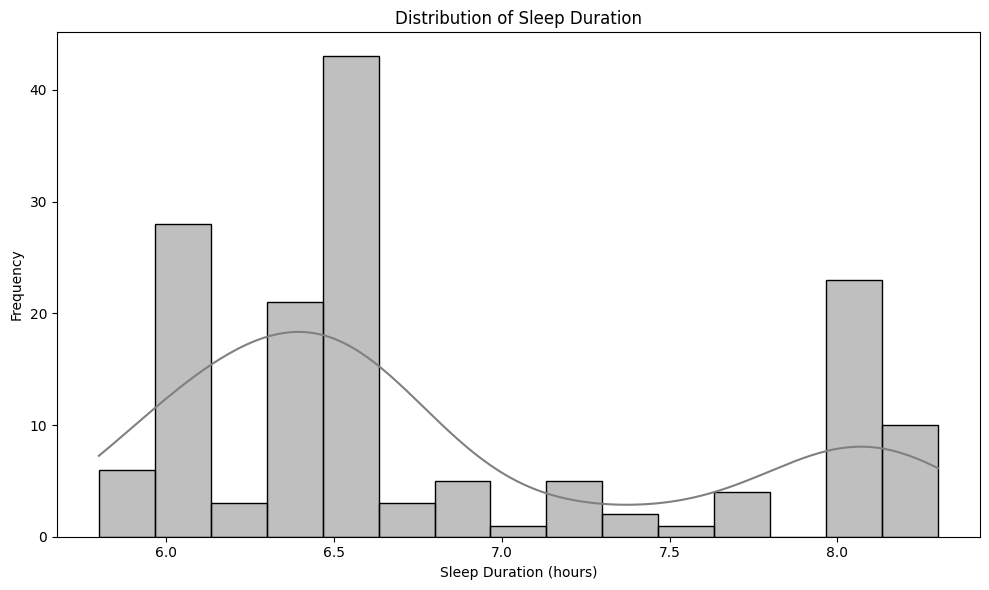

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sleep Duration'], kde=True, bins=15, color='grey')
plt.title('Distribution of Sleep Duration')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

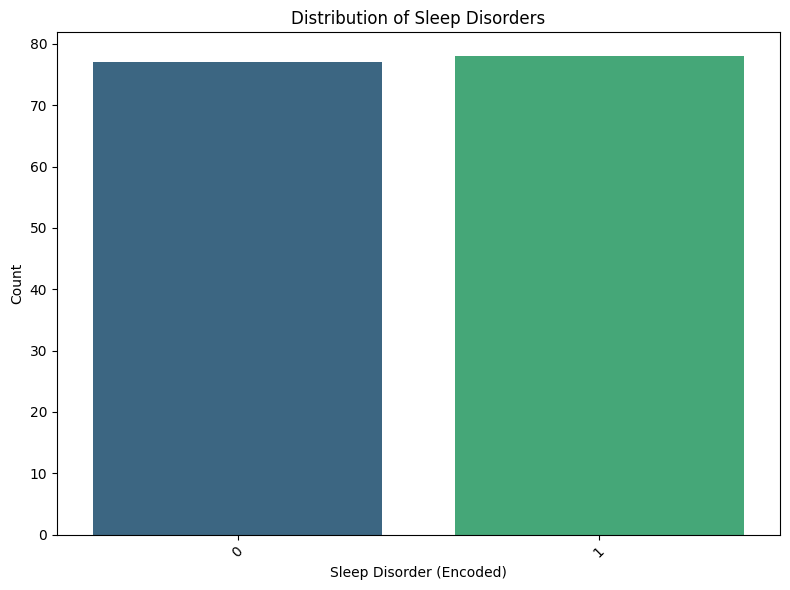

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sleep Disorder', data=df, palette='viridis', hue='Sleep Disorder', legend=False)
plt.title('Distribution of Sleep Disorders')
plt.xlabel('Sleep Disorder (Encoded)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("Before processing")
before_df.head()


Before processing


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
print("After processing")
df.head()

After processing


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic Blood Pressure,...,Occupation_4,Occupation_5,Occupation_6,Occupation_7,Occupation_8,Occupation_9,BMI Category_0,BMI Category_1,BMI Category_2,BMI Category_3
3,1,28,5.9,4,30,8,85,3000,1,140,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,28,5.9,4,30,8,85,3000,1,140,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,1,28,5.9,4,30,8,85,3000,0,140,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6,1,29,6.3,6,40,7,82,3500,0,140,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
16,0,29,6.5,5,40,7,80,4000,1,132,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
